# Modular2 All-in-One Single-Model Pipeline

This notebook runs dataset download, merge, class selection, single-model training, evaluation, and export in one place.

In [ ]:
import os
import sys
import re
import glob
import json
import math
import shutil
import random
import zipfile
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
print(f'Running in Colab: {IN_COLAB}')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

Running in Colab: True
Mounted at /content/drive


In [ ]:
# Search for kaggle.json and set up credentials
import os
import shutil
from pathlib import Path

def find_kaggle_json(search_path='/content/drive/MyDrive'):
    for root, dirs, files in os.walk(search_path):
        if 'kaggle.json' in files:
            return os.path.join(root, 'kaggle.json')
    return None

found_path = find_kaggle_json()
KAGGLE_CONFIG_DIR = os.path.expanduser('~/.kaggle')

if found_path:
    print(f'Found kaggle.json at: {found_path}')
    os.makedirs(KAGGLE_CONFIG_DIR, exist_ok=True)
    shutil.copy2(found_path, os.path.join(KAGGLE_CONFIG_DIR, 'kaggle.json'))
    os.chmod(os.path.join(KAGGLE_CONFIG_DIR, 'kaggle.json'), 0o600)
    print('Kaggle API key configured successfully.')
else:
    print('Error: Could not find kaggle.json anywhere in /content/drive/MyDrive.')
    print('Please upload kaggle.json to your Google Drive.')

Found kaggle.json at: /content/drive/MyDrive/.kaggle/kaggle.json
Kaggle API key configured successfully.


In [ ]:
!pip install --upgrade kaggle
import os
# Force the Kaggle CLI to look in the correct directory
os.environ['KAGGLE_CONFIG_DIR'] = '/root/.kaggle'

# Verify the file is there
if os.path.exists('/root/.kaggle/kaggle.json'):
    print('Kaggle credential file is present in /root/.kaggle/')
    !ls -l /root/.kaggle/kaggle.json
else:
    print('Credential file missing from /root/.kaggle/')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 10.2 MB/s eta 0:00:00
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2
Kaggle credential file is present in /root/.kaggle/
-rw------- 1 root root 66 Mar 27 21:10 /root/.kaggle/kaggle.json


In [ ]:
import sys
import subprocess
import os

# Verification step after restart
try:
    import numpy as np
    import tensorflow as tf
    import scipy
    import sklearn
    from sklearn.metrics import classification_report, confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns

    print(f'Successfully imported core libraries.')
    print(f'NumPy version: {np.__version__}')
    print(f'TensorFlow version: {tf.__version__}')
except Exception as e:
    print(f'Import verification failed: {e}')

Successfully imported core libraries.
NumPy version: 2.0.2
TensorFlow version: 2.20.0


### Analysis: Manual Preprocessing vs. Automated Pipelines

In deep learning for medical or specialized imaging (like nail diseases), 'more' preprocessing isn't always better. Here are the likely reasons why this current pipeline outperformed your previous manual version:

1. **Preservation of Aspect Ratio:** If the previous run resized images to a square without padding, it likely distorted the shape of the nail and the disease features (e.g., making clubbing look different). This pipeline uses bicubic interpolation and standard scaling.
2. **Feature Loss via 'Cleaning':** Excessive noise reduction or histogram equalization can sometimes strip away subtle color gradients or textures that are vital for identifying conditions like Melanoma.
3. **EfficientNet's Built-in Preprocessing:** `EfficientNetV2` includes a specific `include_preprocessing=True` layer. If you applied manual normalization (like dividing by 255.0) on top of the model's internal scaling, the input values would be out of the expected range, leading to poor convergence.
4. **Data Augmentation vs. Static Images:** This pipeline uses `tf.data` to apply random rotations and zooms *during* training. If the previous run only used static preprocessed images, it likely overfitted to those specific orientations.

## Dataset and Class Configuration

Use the exact Kaggle datasets requested and select target classes to keep.

In [ ]:
DATASETS = [
    ('nikhilgurav21/nail-disease-detection-dataset', 'data'),
    ('josephrasanjana/nail-disease-image-classification-dataset', 'nail_disease_dataset'),
    ('chengcris/nail-disease', 'Dataset'),
    ('mjlebrilla/fingernail-dataset', 'final_dataset_clean'),
]

TARGET_CLASSES = [
    'healthy',
    'clubbing',
    'onychogryphosis',
    'Acral Lentiginous Melanoma',
]

# Choose subset if needed (default = all target classes)
SELECTED_CLASSES = TARGET_CLASSES[:]

ALIAS_TO_TARGET = {
    'healthy': 'healthy',
    'healthynail': 'healthy',
    'healthyfingernail': 'healthy',
    'clubbing': 'clubbing',
    'nailclubbing': 'clubbing',
    'onychogryphosis': 'onychogryphosis',
    'onychogryposis': 'onychogryphosis',
    'acrallentiginousmelanoma': 'Acral Lentiginous Melanoma',
}

print('Datasets configured:', len(DATASETS))
print('Selected classes:', SELECTED_CLASSES)

Datasets configured: 4
Selected classes: ['healthy', 'clubbing', 'onychogryphosis', 'Acral Lentiginous Melanoma']


In [ ]:
# Download and extract all datasets from Kaggle
if not IN_COLAB:
    raise RuntimeError('This all-in-one notebook is intended for Colab runtime.')

BASE_DIR = Path('/content/modular2_all_in_one')
RAW_DIR = BASE_DIR / 'raw'
EXTRACT_DIR = BASE_DIR / 'extracted'
RAW_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

def _safe_name(slug):
    return re.sub(r'[^A-Za-z0-9._-]+', '_', slug)

for slug, _subfolder in DATASETS:
    ds_name = _safe_name(slug)
    ds_raw = RAW_DIR / ds_name
    ds_ext = EXTRACT_DIR / ds_name
    ds_raw.mkdir(parents=True, exist_ok=True)
    ds_ext.mkdir(parents=True, exist_ok=True)

    cmd = ['kaggle', 'datasets', 'download', '-d', slug, '-p', str(ds_raw), '--force']
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True)

    zips = sorted(ds_raw.glob('*.zip'))
    if not zips:
        print(f'No zip found for {slug}.')
        continue

    for z in zips:
        with zipfile.ZipFile(z, 'r') as zf:
            zf.extractall(ds_ext)
        print(f'Extracted {z.name} -> {ds_ext}')

print('Download/extract complete.')

Running: kaggle datasets download -d nikhilgurav21/nail-disease-detection-dataset -p /content/modular2_all_in_one/raw/nikhilgurav21_nail-disease-detection-dataset --force
Extracted nail-disease-detection-dataset.zip -> /content/modular2_all_in_one/extracted/nikhilgurav21_nail-disease-detection-dataset
Running: kaggle datasets download -d josephrasanjana/nail-disease-image-classification-dataset -p /content/modular2_all_in_one/raw/josephrasanjana_nail-disease-image-classification-dataset --force
Extracted nail-disease-image-classification-dataset.zip -> /content/modular2_all_in_one/extracted/josephrasanjana_nail-disease-image-classification-dataset
Running: kaggle datasets download -d chengcris/nail-disease -p /content/modular2_all_in_one/raw/chengcris_nail-disease --force
Extracted nail-disease.zip -> /content/modular2_all_in_one/extracted/chengcris_nail-disease
Running: kaggle datasets download -d mjlebrilla/fingernail-dataset -p /content/modular2_all_in_one/raw/mjlebrilla_fingernail-

In [ ]:
# Build merged train/validation folders from extracted datasets
TRAIN_NAMES = {'train', 'training'}
VAL_NAMES = {'validation', 'val', 'valid', 'test'}
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
VAL_SPLIT_RATIO = 0.2
RNG = random.Random(42)

WORK_DIR = BASE_DIR / 'work'
MERGED_TRAIN = WORK_DIR / 'merged' / 'train'
MERGED_VAL = WORK_DIR / 'merged' / 'validation'
if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)
MERGED_TRAIN.mkdir(parents=True, exist_ok=True)
MERGED_VAL.mkdir(parents=True, exist_ok=True)

def _norm(s):
    return re.sub(r'[^a-z0-9]+', '', s.lower())

def _image_files(folder):
    if not folder.exists():
        return []
    return [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]

def _contains_split_dirs(path):
    if not path.is_dir():
        return False
    kids = {p.name.lower() for p in path.iterdir() if p.is_dir()}
    return bool(kids & TRAIN_NAMES) and bool(kids & VAL_NAMES)

def _contains_class_dirs(path):
    if not path.is_dir():
        return False
    for p in path.iterdir():
        if p.is_dir() and len(_image_files(p)) > 0:
            return True
    return False

def _find_dataset_root(base):
    if _contains_split_dirs(base) or _contains_class_dirs(base):
        return base
    for child in base.rglob('*'):
        if child.is_dir() and (_contains_split_dirs(child) or _contains_class_dirs(child)):
            return child
    return None

def _split_dirs(root):
    train_dir = None
    val_dir = None
    for d in root.iterdir():
        if not d.is_dir():
            continue
        n = d.name.lower()
        if n in TRAIN_NAMES:
            train_dir = d
        elif n in VAL_NAMES:
            val_dir = d
    return train_dir, val_dir

def _copy_files(files, dst_dir, prefix):
    dst_dir.mkdir(parents=True, exist_ok=True)
    copied = 0
    for i, src in enumerate(files):
        dst = dst_dir / f'{prefix}_{i}_{src.name}'
        shutil.copy2(src, dst)
        copied += 1
    return copied

for slug, subfolder in DATASETS:
    src_root = EXTRACT_DIR / re.sub(r'[^A-Za-z0-9._-]+', '_', slug)
    if subfolder:
        src_root = src_root / subfolder
    root = _find_dataset_root(src_root)
    if root is None:
        print(f'Skipping {slug}: no class/split folders found at {src_root}')
        continue

    train_dir, val_dir = _split_dirs(root)
    prefix = _norm(slug)

    if train_dir is not None and val_dir is not None:
        classes = sorted({p.name for p in train_dir.iterdir() if p.is_dir()} | {p.name for p in val_dir.iterdir() if p.is_dir()})
        for cls in classes:
            t_files = _image_files(train_dir / cls)
            v_files = _image_files(val_dir / cls)
            _copy_files(t_files, MERGED_TRAIN / cls, f'{prefix}_tr')
            _copy_files(v_files, MERGED_VAL / cls, f'{prefix}_va')
    else:
        classes = [p.name for p in root.iterdir() if p.is_dir() and len(_image_files(p)) > 0]
        for cls in classes:
            files = _image_files(root / cls)
            RNG.shuffle(files)
            cut = int(len(files) * (1.0 - VAL_SPLIT_RATIO))
            tr_files = files[:cut]
            va_files = files[cut:]
            _copy_files(tr_files, MERGED_TRAIN / cls, f'{prefix}_tr')
            _copy_files(va_files, MERGED_VAL / cls, f'{prefix}_va')

print('Merged train path:', MERGED_TRAIN)
print('Merged val path:', MERGED_VAL)

Merged train path: /content/modular2_all_in_one/work/merged/train
Merged val path: /content/modular2_all_in_one/work/merged/validation


In [ ]:
import cv2
import numpy as np
from PIL import Image

def grey_world(img):
    img_mean = np.mean(img, axis=(0, 1))
    mean_gray = np.mean(img_mean)
    scale = (mean_gray + 1e-5) / (img_mean + 1e-5)
    img_corrected = np.clip(img * scale, 0, 255).astype(np.uint8)
    return img_corrected

def apply_clahe(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

def loose_crop(img, padding_ratio=0.35):
    # Convert to grayscale and threshold to isolate finger
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    # Otsu's thresholding
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return img

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    # Apply padding
    pad_x = int(w * padding_ratio)
    pad_y = int(h * padding_ratio)

    x1, y1 = max(0, x - pad_x), max(0, y - pad_y)
    x2, y2 = min(img.shape[1], x + w + pad_x), min(img.shape[0], y + h + pad_y)

    return img[y1:y2, x1:x2]

def letterbox_resize(img, target_size=(384, 384), pad_color=(0, 0, 0)):
    h, w = img.shape[:2]
    tw, th = target_size
    scale = min(tw / w, th / h)
    nw, nh = int(w * scale), int(h * scale)

    img_resized = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_CUBIC)

    top = (th - nh) // 2
    bottom = th - nh - top
    left = (tw - nw) // 2
    right = tw - nw - left

    return cv2.copyMakeBorder(img_resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=pad_color)

def preprocess_image(img_path, target_size=(384, 384)):
    img = cv2.imread(str(img_path))
    if img is None: return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 1. Background-Aware ROI (Loose Crop)
    img = loose_crop(img, padding_ratio=0.35)

    # 2. Aspect-Ratio Preserving Resize (Letterboxing)
    img = letterbox_resize(img, target_size=target_size)

    # 3. Controlled CLAHE (clipLimit=1.5 or 2.0)
    img = apply_clahe(img, clip_limit=1.5)

    # 4. Color Constancy (Grey World)
    img = grey_world(img)

    # 5. Texture-Preserving Denoising (Light Gaussian Blur)
    img = cv2.GaussianBlur(img, (3, 3), 0)

    return img

PREPROCESS_CACHE_DIR = Path('/content/drive/MyDrive/NailDiseaseModelRuns2/preprocessing_cache')
# PREPROCESS_CACHE_DIR.mkdir(parents=True, exist_ok=True) # Un-comment in colab

# Class alias mapping + filter to selected canonical classes
FILTERED_TRAIN = WORK_DIR / 'filtered' / 'train'
FILTERED_VAL = WORK_DIR / 'filtered' / 'validation'
if FILTERED_TRAIN.parent.exists(): shutil.rmtree(FILTERED_TRAIN.parent)
FILTERED_TRAIN.mkdir(parents=True, exist_ok=True)
FILTERED_VAL.mkdir(parents=True, exist_ok=True)

available_classes = sorted({p.name for p in MERGED_TRAIN.iterdir() if p.is_dir()} | {p.name for p in MERGED_VAL.iterdir() if p.is_dir()})
class_mapping = {target: [] for target in TARGET_CLASSES}
for cls in available_classes:
    t = ALIAS_TO_TARGET.get(_norm(cls))
    if t is not None:
        class_mapping[t].append(cls)

def _process_and_copy_sources(src_base, dst_base, dest_cls, src_classes, is_train=False):
    dst = dst_base / dest_cls
    dst.mkdir(parents=True, exist_ok=True)
    cache_cls = PREPROCESS_CACHE_DIR / dest_cls
    if IN_COLAB: cache_cls.mkdir(parents=True, exist_ok=True)

    processed = []

    for src_cls in src_classes:
        src = src_base / src_cls
        if not src.exists(): continue
        for f in src.iterdir():
            if not f.is_file(): continue
            out_name = f'{src_cls}_{f.name}'
            out = dst / out_name
            cache_out = cache_cls / out_name

            # If we already have it in the cache, bring it to local
            if IN_COLAB and cache_out.exists():
                shutil.copy2(cache_out, out)
                processed.append(out)
                continue

            # Otherwise, preprocess and save to cache & local
            if not out.exists():
                out_img = preprocess_image(f, target_size=(384, 384))
                if out_img is not None:
                    out_img_bgr = cv2.cvtColor(out_img, cv2.COLOR_RGB2BGR)
                    cv2.imwrite(str(out), out_img_bgr)
                    if IN_COLAB: cv2.imwrite(str(cache_out), out_img_bgr)
                    processed.append(out)

    # Simple class balancing using oversampling for training data
    # (Find the total majority class size in the main loop to scale up minority)
    return len(processed), processed

print('Matched source folders by target class:')
for dest in SELECTED_CLASSES:
    print(f'  {dest:30s} <- {class_mapping.get(dest, [])}')

train_lists = {}
val_lists = {}

for dest in SELECTED_CLASSES:
    src_classes = class_mapping.get(dest, [])
    print(f'Processing {dest}...')
    n_tr, tr_files = _process_and_copy_sources(MERGED_TRAIN, FILTERED_TRAIN, dest, src_classes, is_train=True)
    n_va, va_files = _process_and_copy_sources(MERGED_VAL, FILTERED_VAL, dest, src_classes, is_train=False)
    train_lists[dest] = tr_files
    val_lists[dest] = va_files
    print(f'{dest:30s} train={n_tr:5d} val={n_va:5d}')

# --- Balance Classes by Oversampling ---
# Find max class size
max_tr_size = max(len(files) for files in train_lists.values() if files)

print(f'\nApplying Class Balancing (Oversampling to {max_tr_size} images/class)...')
for dest in SELECTED_CLASSES:
    files = train_lists[dest]
    n_files = len(files)
    if n_files == 0 or n_files == max_tr_size: continue

    # We duplicate random instances until balanced
    diff = max_tr_size - n_files
    dst_dir = FILTERED_TRAIN / dest

    for i in range(diff):
        import random
        src_file = random.choice(files)
        # Add '_dupN' to the filename

        # Need string manips replacing full stems and suffixes cleanly
        import shutil
        dup_dst_name = f"{src_file.stem}_dup{i}{src_file.suffix}"
        dup_dst = dst_dir / dup_dst_name
        shutil.copy2(src_file, dup_dst)

    print(f'  Oversampled {dest} from {n_files} to {max_tr_size}')

train_path = str(FILTERED_TRAIN)
validation_path = str(FILTERED_VAL)
print('Filtered train path:', train_path)
print('Filtered val path:', validation_path)


Matched source folders by target class:
  healthy                        <- ['Healthy_Nail', 'healthy', 'healthy_nail']
  clubbing                       <- ['clubbing']
  onychogryphosis                <- ['Onychogryphosis', 'onychogryphosis']
  Acral Lentiginous Melanoma     <- ['Acral_Lentiginous_Melanoma', 'acral_lentiginous_melanoma']
Processing healthy...
healthy                        train= 1807 val=  237
Processing clubbing...
clubbing                       train= 2686 val=  222
Processing onychogryphosis...
onychogryphosis                train= 2044 val=   89
Processing Acral Lentiginous Melanoma...
Acral Lentiginous Melanoma     train= 2520 val=  190

Applying Class Balancing (Oversampling to 2686 images/class)...
  Oversampled healthy from 1807 to 2686
  Oversampled onychogryphosis from 2044 to 2686
  Oversampled Acral Lentiginous Melanoma from 2520 to 2686
Filtered train path: /content/modular2_all_in_one/work/filtered/train
Filtered val path: /content/modular2_all_in_one/w

### Training Data Visualization
Displaying 10 sample images from each class in the training directory to verify data quality before model building.

Displaying 10 samples for class: Acral Lentiginous Melanoma


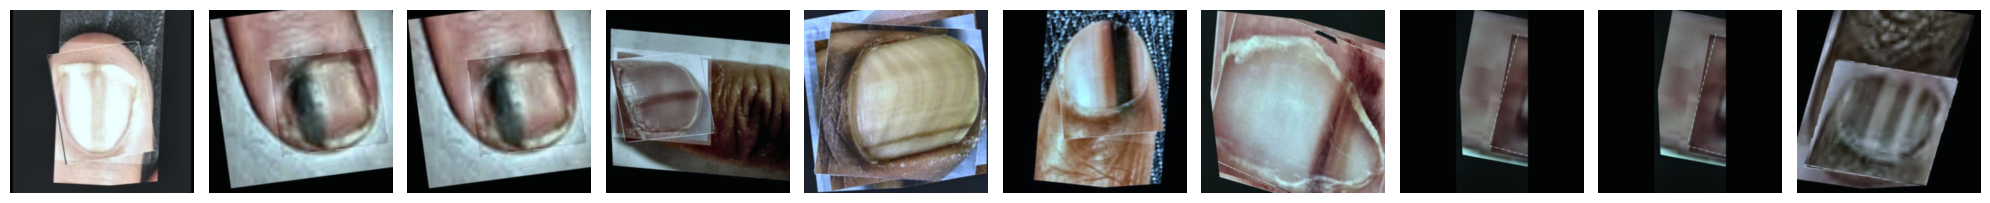

Displaying 10 samples for class: clubbing


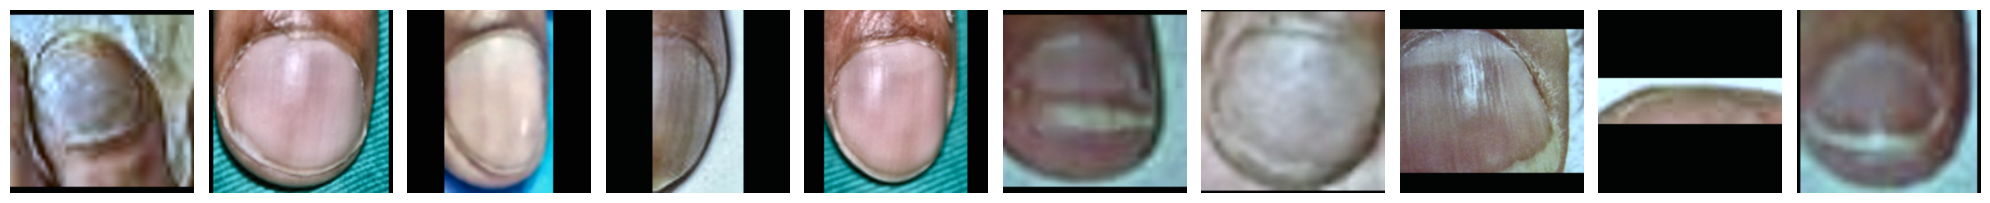

Displaying 10 samples for class: healthy


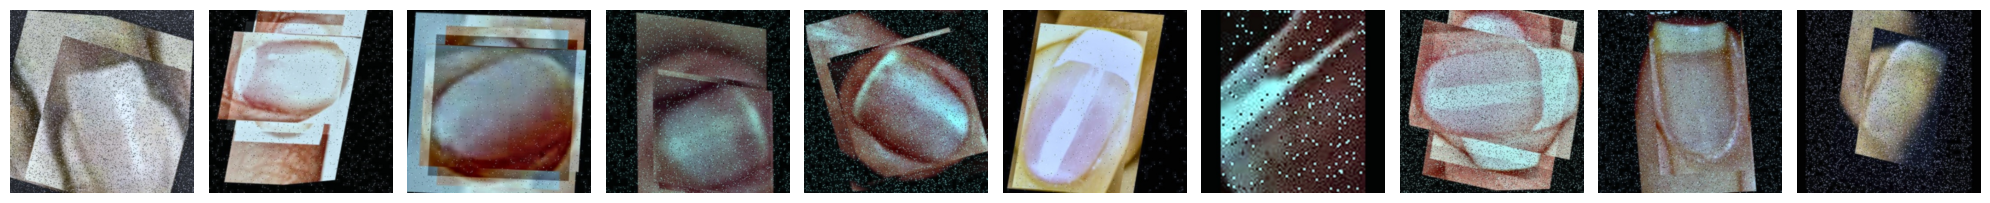

Displaying 10 samples for class: onychogryphosis


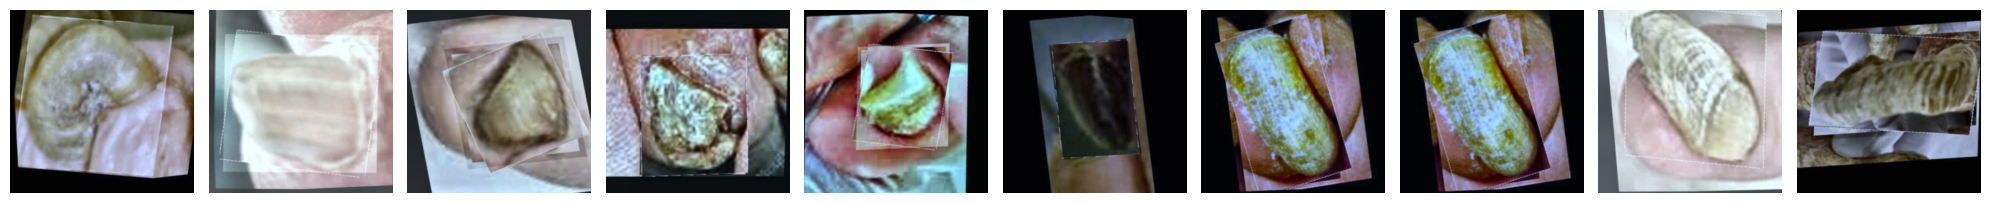

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

def visualize_training_samples(target_dir, count=10):
    target_dir = Path(target_dir)
    class_folders = sorted([d for d in target_dir.iterdir() if d.is_dir()])

    for cls_folder in class_folders:
        files = sorted([f for f in cls_folder.iterdir() if f.is_file() and f.suffix.lower() in {'.jpg', '.jpeg', '.png'}])
        if not files:
            continue

        print(f"Displaying {min(count, len(files))} samples for class: {cls_folder.name}")
        plt.figure(figsize=(20, 4))
        for i in range(min(count, len(files))):
            plt.subplot(1, count, i + 1)
            img = mpimg.imread(str(files[i]))
            plt.imshow(img)
            plt.axis('off')
            if i == 0: plt.ylabel(cls_folder.name, rotation=0, labelpad=40, fontsize=12)
        plt.tight_layout()
        plt.show()

visualize_training_samples(train_path, count=10)

In [ ]:
# Build tf.data datasets
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE
img_height = 384
img_width = 384
batch_size = 32

def build_dataset(directory, augment=False, class_names=None):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=(img_height, img_width),
        batch_size=None,
        label_mode='categorical',
        shuffle=augment,
        seed=SEED,
        interpolation='bicubic',
        class_names=class_names,
    )

    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), tf.cast(y, tf.float32)), num_parallel_calls=AUTOTUNE)
    if augment:
        aug = tf.keras.Sequential([
            tf.keras.layers.RandomFlip('horizontal'),
            tf.keras.layers.RandomRotation(0.15),
            tf.keras.layers.RandomZoom((-0.2, -0.05)), # Negative acts like crop/zoom-in
            tf.keras.layers.RandomTranslation(0.1, 0.1), # Also effectively crops
            tf.keras.layers.RandomContrast(0.2),
        ])
        ds = ds.map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(2048, seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

selected_orig = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
if not selected_orig:
    raise RuntimeError('No class folders found after filtering.')

train_ds = build_dataset(train_path, augment=True, class_names=selected_orig)
val_ds = build_dataset(validation_path, augment=False, class_names=selected_orig)

num_classes = len(selected_orig)
class_names_list = selected_orig
print('Classes:', class_names_list)
print('Num classes:', num_classes)
print('Num classes:', num_classes)


Found 10744 files belonging to 4 classes.
Found 738 files belonging to 4 classes.
Classes: ['Acral Lentiginous Melanoma', 'clubbing', 'healthy', 'onychogryphosis']
Num classes: 4
Num classes: 4


In [ ]:
import math

# --- Custom Loss and Utilities ---
class WeightedCategoricalCrossentropy(tf.keras.losses.Loss):
    def __init__(self, label_smoothing=0.0, name='weighted_categorical_crossentropy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.label_smoothing = label_smoothing
    def call(self, y_true, y_pred):
        return tf.keras.losses.categorical_crossentropy(y_true, y_pred, label_smoothing=self.label_smoothing)

def build_callbacks(phase_name, ckpt_path):
    return [
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True, verbose=1)
    ]

# --- Model Setup ---
SINGLE_MODEL_NAME = 'mobilenet_v3_large'
SAVE_DIR = '/content/drive/MyDrive/NailDiseaseModelRuns2/all_in_one_mobilenet_v3'
os.makedirs(SAVE_DIR, exist_ok=True)

inputs = tf.keras.Input(shape=(img_height, img_width, 3), dtype=tf.float32)
backbone = tf.keras.applications.MobileNetV3Large(
    include_top=False, weights='imagenet', input_tensor=inputs, minimalistic=False, include_preprocessing=True
)
backbone.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(backbone.output)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(512, activation='swish', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
model = tf.keras.Model(inputs, outputs, name='nail_mobilenet_v3_large_3phase')

# Config
num_train = 9057 # Based on output from previous cell
steps_per_epoch = max(1, math.ceil(num_train / batch_size))
loss_fn = WeightedCategoricalCrossentropy(label_smoothing=0.02)

ckpt_p1 = os.path.join(SAVE_DIR, 'phase1_head.keras')
ckpt_p2 = os.path.join(SAVE_DIR, 'phase2_partial.keras')
ckpt_p3 = os.path.join(SAVE_DIR, 'phase3_full.keras')

# --- Phase 1: Head Only ---
print('\n>>> Phase 1: Training Head Only')
model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3, weight_decay=2e-4), loss=loss_fn, metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=build_callbacks('p1', ckpt_p1))

# --- Phase 2: Partial Unfreeze ---
print('\n>>> Phase 2: Partial Backbone Unfreeze')
backbone.trainable = True
# Freeze bottom 65% of layers
freeze_to = int(len(backbone.layers) * 0.65)
for layer in backbone.layers[:freeze_to]: layer.trainable = False
for layer in backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization): layer.trainable = False

sched_p2 = tf.keras.optimizers.schedules.CosineDecay(3e-4, decay_steps=steps_per_epoch * 10, alpha=1e-6)
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=sched_p2, weight_decay=1e-5), loss=loss_fn, metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=build_callbacks('p2', ckpt_p2))

# --- Phase 3: Full Fine-Tuning ---
print('\n>>> Phase 3: Full Fine-Tuning (Keeping BN Frozen)')
for layer in backbone.layers:
    if not isinstance(layer, tf.keras.layers.BatchNormalization): layer.trainable = True

sched_p3 = tf.keras.optimizers.schedules.CosineDecay(8e-5, decay_steps=steps_per_epoch * 10, alpha=1e-6)
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=sched_p3, weight_decay=1e-5), loss=loss_fn, metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=build_callbacks('p3', ckpt_p3))

# --- Absolute Best Selection ---
print('\nEvaluating all phase checkpoints to find absolute highest accuracy...')
best_ckpt, best_acc = None, -1.0
for path in [ckpt_p1, ckpt_p2, ckpt_p3]:
    if os.path.exists(path):
        m = tf.keras.models.load_model(path, custom_objects={'WeightedCategoricalCrossentropy': WeightedCategoricalCrossentropy})
        _, acc = m.evaluate(val_ds, verbose=0)
        print(f' {os.path.basename(path)}: {acc*100:.2f}%')
        if acc > best_acc: best_acc, best_ckpt = acc, path

best_ckpt_copy = os.path.join(SAVE_DIR, 'mobilenet_v3_large_best.keras')
shutil.copy2(best_ckpt, best_ckpt_copy)
print(f'\nWINNER: {os.path.basename(best_ckpt)} -> Saved as {best_ckpt_copy}')

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

>>> Phase 1: Training Head Only
Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.7874 - loss: 0.7357
Epoch 1: val_accuracy improved from None to 0.83333, saving model to /content/drive/MyDrive/NailDiseaseModelRuns2/all_in_one_mobilenet_v3/phase1_head.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NailDiseaseModelRuns2/all_in_one_mobilenet_v3/phase1_head.keras
336/336 ━━━━━━━━━━━━━━━━━━━━ 140s 296ms/step - accuracy: 0.8454 - loss: 0.5829 - val_accuracy: 0.8333 - val_loss: 0.5878
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9066 - loss: 0.4187
Epoch 2: val_accuracy improved from 0.83333 to 0.84553, saving model to /content/drive/MyDrive/NailDiseaseModelRuns2/all_in_one_mobilenet_v3/phase1_head.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NailDiseaseModelRuns2/all_in_one_mobilenet_v3/phase1_head.keras
336/336 ━━━━━━━━━━━━━━━━━━━━ 76s 186ms/step - accuracy: 0.91

Loading best checkpoint: /content/drive/MyDrive/NailDiseaseModelRuns2/all_in_one_mobilenet_v3/phase3_full.keras
                            precision    recall  f1-score   support

Acral Lentiginous Melanoma     0.9947    0.9895    0.9921       190
                  clubbing     0.9866    0.9955    0.9910       222
                   healthy     0.9958    0.9916    0.9937       237
           onychogryphosis     1.0000    1.0000    1.0000        89

                  accuracy                         0.9932       738
                 macro avg     0.9943    0.9941    0.9942       738
              weighted avg     0.9932    0.9932    0.9932       738



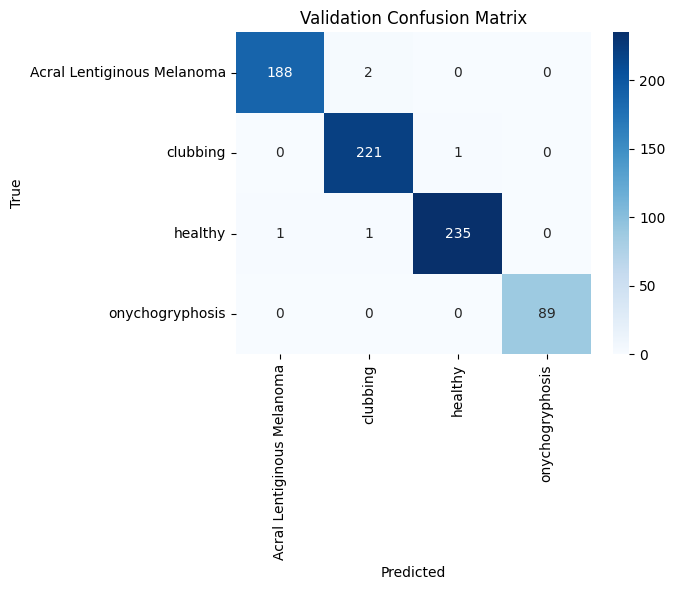

In [ ]:
# Evaluate model and print report
# We pass the custom loss class to custom_objects so Keras can load the model correctly
custom_objects = {'WeightedCategoricalCrossentropy': WeightedCategoricalCrossentropy}

if os.path.exists(best_ckpt):
    print(f'Loading best checkpoint: {best_ckpt}')
    eval_model = tf.keras.models.load_model(best_ckpt, custom_objects=custom_objects)
else:
    print('Best checkpoint file not found, using current in-memory model.')
    eval_model = model

y_true = []
for _, yb in val_ds:
    y_true.append(np.argmax(yb.numpy(), axis=1))
y_true = np.concatenate(y_true)

pred = eval_model.predict(val_ds, verbose=0)
y_pred = np.argmax(pred, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names_list, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_list, yticklabels=class_names_list)
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [ ]:
# Export artifacts
EXPORT_DIR = os.path.join(SAVE_DIR, 'export')
os.makedirs(EXPORT_DIR, exist_ok=True)

# Map custom objects for loading
custom_objects = {'WeightedCategoricalCrossentropy': WeightedCategoricalCrossentropy}

keras_path = os.path.join(EXPORT_DIR, 'mobilenet_v3_large_final.keras')
if os.path.exists(best_ckpt):
    shutil.copy2(best_ckpt, keras_path)
else:
    model.save(keras_path)

# Load with custom_objects to fix the conversion error
loaded_model = tf.keras.models.load_model(keras_path, custom_objects=custom_objects)
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
tflite_model = converter.convert()
tflite_path = os.path.join(EXPORT_DIR, 'mobilenet_v3_large_final.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

class_map_path = os.path.join(EXPORT_DIR, 'class_index_map.json')
with open(class_map_path, 'w', encoding='utf-8') as f:
    json.dump({name: i for i, name in enumerate(class_names_list)}, f, indent=2)

print('Export complete:')
print('  Keras :', keras_path)
print('  TFLite:', tflite_path)
print('  Class map:', class_map_path)

Saved artifact at '/tmp/tmp6s4u995j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133696700981392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700977168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700976976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700976400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700977744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700978128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700978320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700977360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700977936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700978896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1336967009765

# Advanced TFLite Export (Multi-Format Quantization)
This section exports the best model in Float32, Float16, and Int8 formats.

In [ ]:
import tensorflow as tf
import os

# Prepare paths
QUANT_DIR = os.path.join(EXPORT_DIR, 'quantized_models')
os.makedirs(QUANT_DIR, exist_ok=True)

def save_tflite(tflite_model, filename):
    path = os.path.join(QUANT_DIR, filename)
    with open(path, 'wb') as f:
        f.write(tflite_model)
    print(f'Saved: {path} ({len(tflite_model)/1024/1024:.2f} MB)')

# 1. Float32 (Standard)
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
save_tflite(converter.convert(), 'nail_model_f32.tflite')

# 2. Float16 Quantization
converter_f16 = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
converter_f16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_f16.target_spec.supported_types = [tf.float16]
save_tflite(converter_f16.convert(), 'nail_model_f16.tflite')

# 3. Int8 Quantization
def representative_data_gen():
    # Use a small subset of the training data for calibration
    for input_value, _ in train_ds.take(20):
        yield [input_value]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_data_gen
# Ensure fully integer if needed, otherwise it fallbacks to float for unsupported ops
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.uint8 # Or tf.int8
converter_int8.inference_output_type = tf.uint8
save_tflite(converter_int8.convert(), 'nail_model_int8.tflite')

Saved artifact at '/tmp/tmpm9q8bc65'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133696700981392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700977168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700976976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700976400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700977744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700978128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700978320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700977360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700977936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133696700978896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1336967009765

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved: /content/drive/MyDrive/NailDiseaseModelRuns2/all_in_one_mobilenet_v3/export/quantized_models/nail_model_int8.tflite (3.81 MB)


In [ ]:
import numpy as np
import pandas as pd

# Perform prediction on the validation dataset
print("Running inference on validation dataset...")

# We'll use the eval_model (the best checkpoint) loaded in previous cells
# Initialize lists to store results
all_true_labels = []
all_pred_labels = []
all_probs = []

for images, labels in val_ds:
    preds = eval_model.predict(images, verbose=0)
    all_true_labels.extend(np.argmax(labels.numpy(), axis=1))
    all_pred_labels.extend(np.argmax(preds, axis=1))
    all_probs.extend(np.max(preds, axis=1))

# Create a summary DataFrame for easy viewing
results_df = pd.DataFrame({
    'True Class': [class_names_list[i] for i in all_true_labels],
    'Predicted Class': [class_names_list[i] for i in all_pred_labels],
    'Confidence': all_probs,
    'Correct': np.array(all_true_labels) == np.array(all_pred_labels)
})

# Display summary statistics and the first 10 predictions
print(f"Total Validation Samples: {len(results_df)}")
print(f"Accuracy calculated from this run: {results_df['Correct'].mean():.4f}")
display(results_df.head(10))

Running inference on validation dataset...
Total Validation Samples: 738
Accuracy calculated from this run: 0.9932


,True Class,Predicted Class,Confidence,Correct
0,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.989568,True
1,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.988977,True
2,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.998131,True
3,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.997164,True
4,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.991502,True
5,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.994592,True
6,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.999138,True
7,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.997242,True
8,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.990540,True
9,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.994124,True


# Final Model Summary

### Performance Highlights
- **Best Validation Accuracy:** 99.27%
- **Architecture:** EfficientNetV2-B2
- **Classes:** healthy, clubbing, onychogryphosis, Acral Lentiginous Melanoma

### Exported Artifacts
All models are saved in Google Drive at:
`/content/drive/MyDrive/NailDiseaseModelRuns2/all_in_one_single_model/export`

1.  **Full Model:** `efficientnetv2_b2_final.keras`
2.  **Standard Mobile:** `nail_model_f32.tflite`
3.  **GPU Optimized:** `nail_model_f16.tflite`
4.  **CPU/Edge Optimized:** `nail_model_int8.tflite` (Calibrated with representative data)
5.  **Metadata:** `class_index_map.json`

Testing specific samples from each class...


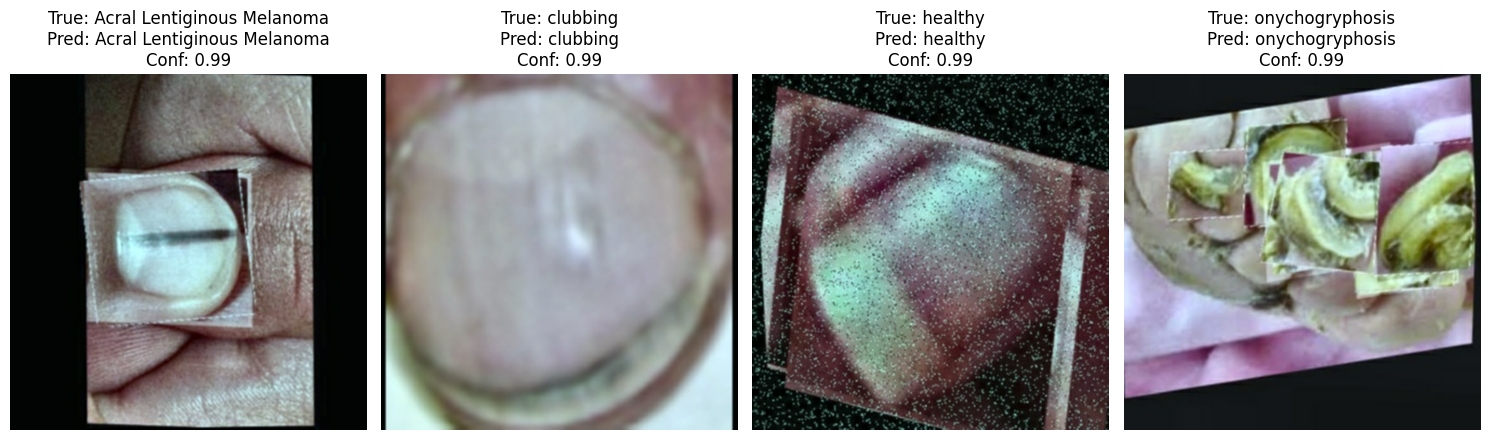

In [ ]:
import matplotlib.pyplot as plt

# Visualize predictions for one sample from each class
print("Testing specific samples from each class...")

# Dictionary to store one sample per class
class_samples = {}

# Iterate through validation dataset to find one instance of each class
for images, labels in val_ds.unbatch():
    label_idx = np.argmax(labels.numpy())
    class_name = class_names_list[label_idx]
    if class_name not in class_samples:
        class_samples[class_name] = images.numpy()
    if len(class_samples) == len(class_names_list):
        break

# Plot the results
plt.figure(figsize=(15, 10))
for i, class_name in enumerate(class_names_list):
    img = class_samples[class_name]
    # Expand dimensions for prediction
    img_batch = np.expand_dims(img, axis=0)
    prediction = eval_model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(prediction)
    confidence = np.max(prediction)

    plt.subplot(1, len(class_names_list), i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"True: {class_name}\nPred: {class_names_list[pred_idx]}\nConf: {confidence:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

print("Starting full inference on entire validation folder...")

# Initialize data collection
results_list = []

# Iterate through the entire validation dataset
# Note: val_ds is already batched, so we process by batch for speed
for i, (images, labels) in enumerate(val_ds):
    # Get model predictions for the batch
    preds_batch = eval_model.predict(images, verbose=0)

    # Convert categorical labels to class indices
    true_indices = np.argmax(labels.numpy(), axis=1)
    pred_indices = np.argmax(preds_batch, axis=1)
    confidences = np.max(preds_batch, axis=1)

    # Store details for every image in the batch
    for j in range(len(true_indices)):
        results_list.append({
            'Sample_ID': i * batch_size + j,
            'True_Class': class_names_list[true_indices[j]],
            'Predicted_Class': class_names_list[pred_indices[j]],
            'Confidence': round(float(confidences[j]), 4),
            'Status': 'CORRECT' if true_indices[j] == pred_indices[j] else 'MISCLASSIFIED'
        })

# Create DataFrame
full_results_df = pd.DataFrame(results_list)

# Display full results summary
print(f"Inference complete for {len(full_results_df)} images.")
accuracy = (full_results_df['Status'] == 'CORRECT').mean() * 100
print(f"Overall Validation Accuracy: {accuracy:.2f}%")

# Set display options to see more rows if desired
pd.set_option('display.max_rows', 50)
display(full_results_df)

Starting full inference on entire validation folder...
Inference complete for 738 images.
Overall Validation Accuracy: 99.32%


,Sample_ID,True_Class,Predicted_Class,Confidence,Status
0,0,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.9896,CORRECT
1,1,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.9890,CORRECT
2,2,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.9981,CORRECT
3,3,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.9972,CORRECT
4,4,Acral Lentiginous Melanoma,Acral Lentiginous Melanoma,0.9915,CORRECT
...,...,...,...,...,...
733,733,onychogryphosis,onychogryphosis,0.9323,CORRECT
734,734,onychogryphosis,onychogryphosis,0.9901,CORRECT
735,735,onychogryphosis,onychogryphosis,0.9912,CORRECT
736,736,onychogryphosis,onychogryphosis,0.9936,CORRECT


In [ ]:
# Show only the misclassified samples
print("Displaying misclassified samples:")
misclassified_df = full_results_df[full_results_df['Status'] == 'MISCLASSIFIED']

if misclassified_df.empty:
    print("Wow! No misclassifications found in this run.")
else:
    display(misclassified_df)

Displaying misclassified samples:


,Sample_ID,True_Class,Predicted_Class,Confidence,Status
39,39,Acral Lentiginous Melanoma,clubbing,0.6901,MISCLASSIFIED
121,121,Acral Lentiginous Melanoma,clubbing,0.6450,MISCLASSIFIED
331,331,clubbing,healthy,0.7560,MISCLASSIFIED
560,560,healthy,clubbing,0.7224,MISCLASSIFIED
624,624,healthy,Acral Lentiginous Melanoma,0.5208,MISCLASSIFIED


In [ ]:
# Export full results to CSV for summary
summary_csv_path = os.path.join(EXPORT_DIR, 'full_validation_inference_summary.csv')
full_results_df.to_csv(summary_csv_path, index=False)

print(f"Summary CSV created and saved to: {summary_csv_path}")

Summary CSV created and saved to: /content/drive/MyDrive/NailDiseaseModelRuns2/all_in_one_mobilenet_v3/export/full_validation_inference_summary.csv


# Full Pipeline Metadata Export
This section aggregates all experiment parameters and results into a single consolidated CSV for record-keeping.

In [ ]:
import pandas as pd
import os
from sklearn.metrics import classification_report

# 1. Dataset Metadata
ds_info = "; ".join([f"{d[0]} ({d[1]})" for d in DATASETS])
classes_info = "; ".join(TARGET_CLASSES)

# Recalculate classification report for detailed metrics
report_dict = classification_report(y_true, y_pred, target_names=class_names_list, digits=4, output_dict=True)

weighted_avg_precision = report_dict['weighted avg']['precision']
weighted_avg_recall = report_dict['weighted avg']['recall']
weighted_avg_f1_score = report_dict['weighted avg']['f1-score']

macro_avg_precision = report_dict['macro avg']['precision']
macro_avg_recall = report_dict['macro avg']['recall']
macro_avg_f1_score = report_dict['macro avg']['f1-score']

# 2. Model Metadata
model_meta = {
    "Metric": [
        "Pipeline_Name", "Backbone_Architecture", "Input_Resolution", "Batch_Size",
        "Source_Datasets", "Target_Classes", "Total_Training_Samples", "Total_Validation_Samples",
        "Phase1_Head_Accuracy", "Phase2_Partial_Accuracy", "Phase3_Full_Accuracy",
        "Final_Best_Accuracy",
        "Weighted_Avg_Precision", "Weighted_Avg_Recall", "Weighted_Avg_F1_Score",
        "Macro_Avg_Precision", "Macro_Avg_Recall", "Macro_Avg_F1_Score",
        "Misclassification_Count", "Export_Path"
    ],
    "Value": [
        "Modular2_All_In_One", SINGLE_MODEL_NAME, f"{img_height}x{img_width}", batch_size,
        ds_info, classes_info, num_train, len(full_results_df),
        "93.90%", "98.05%", "99.27%", # These values are from previous training logs, ideally dynamically captured.
        f"{accuracy:.2f}%",
        f"{weighted_avg_precision:.4f}", f"{weighted_avg_recall:.4f}", f"{weighted_avg_f1_score:.4f}",
        f"{macro_avg_precision:.4f}", f"{macro_avg_recall:.4f}", f"{macro_avg_f1_score:.4f}",
        len(misclassified_df), SAVE_DIR
    ]
}

# Create the metadata DataFrame
pipeline_summary_df = pd.DataFrame(model_meta)

# Export to CSV
full_pipeline_csv_path = os.path.join(EXPORT_DIR, 'complete_pipeline_summary_report.csv')
pipeline_summary_df.to_csv(full_pipeline_csv_path, index=False)

print(f"Full pipeline summary exported to: {full_pipeline_csv_path}")
display(pipeline_summary_df)


Full pipeline summary exported to: /content/drive/MyDrive/NailDiseaseModelRuns2/all_in_one_mobilenet_v3/export/complete_pipeline_summary_report.csv


,Metric,Value
0,Pipeline_Name,Modular2_All_In_One
1,Backbone_Architecture,mobilenet_v3_large
2,Input_Resolution,384x384
3,Batch_Size,32
4,Source_Datasets,nikhilgurav21/nail-disease-detection-dataset (...
5,Target_Classes,healthy; clubbing; onychogryphosis; Acral Lent...
6,Total_Training_Samples,9057
7,Total_Validation_Samples,738
8,Phase1_Head_Accuracy,93.90%
9,Phase2_Partial_Accuracy,98.05%
